In [20]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import cv2

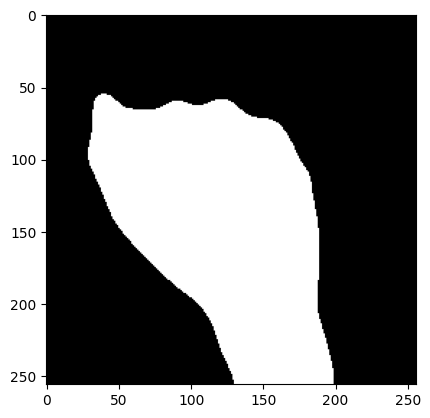

In [10]:
img = image.load_img("data/data/train/fist/1.PNG")
plt.imshow(img)

In [33]:
cv2.imread("data/data/train/fist/1.PNG").shape

(256, 256, 3)

In [6]:
train_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
training_set = train_datagen.flow_from_directory(
        'data/data/train',
        target_size=(64,64),
        batch_size=32,
        color_mode='grayscale',
        class_mode='categorical') #cross_entropy apply one hot

Found 7999 images belonging to 8 classes.


In [11]:
training_set.class_indices

{'fist': 0,
 'five': 1,
 'none': 2,
 'okay': 3,
 'peace': 4,
 'rad': 5,
 'straight': 6,
 'thumbs': 7}

In [12]:
training_set.classes

array([0, 0, 0, ..., 7, 7, 7], shape=(7999,), dtype=int32)

In [8]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [83]:
test_set = test_datagen.flow_from_directory(
        'data/data/test',
        target_size=(64,64),
        batch_size=32, 
        color_mode='grayscale', #converts the image to one single channel(1)
        class_mode='categorical')
images,labels = next(test_set)
print(labels.shape)

Found 4000 images belonging to 8 classes.
(32, 8)


In [14]:
from tensorflow.keras import models,layers

In [24]:
model = models.Sequential([
    #CNN
    layers.Convolution2D(32,(3,3),input_shape=(64,64,1),activation='relu',padding='same'),
    layers.Convolution2D(32,(3,3),input_shape=(64,64,1),activation='relu',padding='same'),
    layers.MaxPooling2D(pool_size=(3,3),strides=2),
    layers.Convolution2D(64,(3,3),input_shape=(64,64,1),activation='relu',padding='same'),
    layers.Convolution2D(64,(3,3),input_shape=(64,64,1),activation='relu',padding='same'),
    layers.MaxPooling2D(pool_size=(3,3),strides=2),

    #Dense
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(64,activation='relu'),
    layers.Dense(8,activation='softmax')
])

C:\Users\HP830G5\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(optimizer='rmsprop',loss='categorical_crossentropy', metrics = ['accuracy'])

In [26]:
history = model.fit(training_set, #batch_size already defined
        epochs=10,
        validation_data=test_set)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 307s 1s/step - accuracy: 0.9195 - loss: 0.2797 - val_accuracy: 0.9550 - val_loss: 0.1763
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 65s 262ms/step - accuracy: 0.9971 - loss: 0.0119 - val_accuracy: 0.9523 - val_loss: 0.2357
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 74s 297ms/step - accuracy: 0.9981 - loss: 0.0048 - val_accuracy: 0.9660 - val_loss: 0.2249
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 330ms/step - accuracy: 1.0000 - loss: 4.0853e-06 - val_accuracy: 0.9632 - val_loss: 0.2862
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 89s 356ms/step - accuracy: 1.0000 - loss: 3.0010e-07 - val_accuracy: 0.9635 - val_loss: 0.2900
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 158s 421ms/step - accuracy: 1.0000 - loss: 2.3218e-07 - val_accuracy: 0.9635 - val_loss: 0.2934
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 112s 448ms/step - accuracy: 1.0000 - loss: 1.7768e-07 - val_accuracy: 0.9640 - val_loss: 0.2960
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 104s 296ms/step - accuracy:

In [42]:
loss, acc = model.evaluate(test_set)
print("Test accuracy:", acc)

125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.9647 - loss: 0.3011
Test accuracy: 0.9647499918937683


In [74]:
from sklearn.metrics import classification_report
import os

test_dir = "data/data/test"
target_size = (64, 64)

# classes
classes = sorted(os.listdir(test_dir)) 

X_test = []
y_test = []

for label_index, class_name in enumerate(classes): 
    class_path = os.path.join(test_dir, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = image.load_img(img_path, target_size=target_size, color_mode='grayscale')
        img_array = image.img_to_array(img) / 255.0 
        X_test.append(img_array)
        y_test.append(label_index) 

X_test = np.array(X_test)         
y_test = np.array(y_test)         

In [82]:
print(y_test)

[0 0 0 ... 7 7 7]


In [72]:
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1) 
print(classification_report(y_test,y_pred_classes))

125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       500
           1       1.00      1.00      1.00       500
           2       0.99      1.00      1.00       500
           3       0.99      1.00      1.00       500
           4       0.98      0.95      0.97       500
           5       0.93      0.99      0.96       500
           6       0.95      0.95      0.95       500
           7       0.92      0.92      0.92       500

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


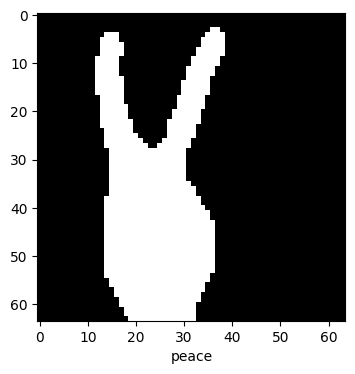

In [73]:
test_img= image.load_img('data/data/test/peace/500.PNG',target_size=(64,64),color_mode='grayscale')
test_img=image.img_to_array(test_img)
test_img = np.expand_dims(test_img,axis=0)
test_img = test_img / 255.0
y_pred = model.predict(test_img) #array of probabilities for each class
predicted_class = np.argmax(y_pred)#index of highest probability
plt.figure(figsize=(4,4))
plt.imshow(test_img[0,:,:,0],cmap='gray')
plt.xlabel(classes[predicted_class])
plt.show()

In [81]:
from tensorflow.keras.models import load_model
model.save('hand_gestures_model.h5') 